# Stock Bubble Detector
### Identifying Overheated Stocks Before They Crash

---

## What Is a Financial Bubble?

A financial bubble happens when a stock's price rises far beyond its real economic value, 
driven by speculation rather than earnings or fundamentals. When confidence breaks, prices collapse fast.

| Bubble | Year | Peak-to-Trough Crash | What Popped It |
|--------|------|---------------------|----------------|
| Dot-Com | 2000 | NASDAQ fell -78% | Earnings reality |
| Housing Crisis | 2008 | S&P 500 fell -57% | Mortgage defaults |
| Crypto Mania | 2021 | Bitcoin fell -77% | Fed rate hikes |
| Meme Stocks | 2021 | GameStop fell -90% | Retail exhaustion |

In every case, four quantifiable warning signs appeared before the crash. This notebook detects all four.

---

## How the Bubble Score Works

Each stock is scored from 0 to 100 across four indicators:

| Indicator | What It Detects | Max Points |
|-----------|-----------------|------------|
| RSI Analysis | Overbought momentum -- prices rising too fast | 30 pts |
| Price vs 200-Day MA | How far above the long-term trend the price has drifted | 30 pts |
| Volatility | Wild price swings indicating speculative activity | 20 pts |
| Price Acceleration | Parabolic, speeding-up moves | 20 pts |

Score guide:

| Score | Risk Level |
|-------|------------|
| 0-9 | Healthy -- no bubble detected |
| 10-29 | Low risk -- monitor monthly |
| 30-49 | Moderate risk -- watch closely |
| 50-69 | High risk -- consider reducing exposure |
| 70-100 | Critical -- bubble conditions present |

---

## Real-World Use Cases

1. Portfolio risk review -- run monthly on your top holdings to catch developing bubbles early
2. Pre-trade check -- before buying a popular stock, verify it is not already overextended
3. Stop-loss calibration -- the strategy engine outputs actual price-specific exit levels
4. Sector rotation timing -- detect when a sector such as AI chips or EVs has gone parabolic
5. Financial advisor screening -- quickly flag risk across a watchlist before client reviews
6. Algorithmic trading filter -- integrate the bubble score as a risk gate in any quant strategy


---
## Step 0 -- Install Libraries (Run Once)

These four libraries are required:

- `yfinance` -- downloads live stock data from Yahoo Finance, no API key needed
- `pandas` -- stores and manipulates price data in table format
- `numpy` -- handles the math: standard deviations, exponentials, rolling calculations
- `matplotlib` -- draws all charts


---
## Step 1 -- Import the Module

We import every function from `stock_bubble_detector.py`.

The module is split into seven sections:

| Section | Contents |
|---------|----------|
| 1 | `load_stock_data()` -- connects to Yahoo Finance and downloads price history |
| 2 | Metric functions -- price, returns, volatility, RSI, moving averages, drawdown |
| 3 | Bubble detection -- four checks that produce the 0-100 score |
| 4 | `generate_strategies()` -- actionable plans scaled to the risk level |
| 5 | Print functions -- formatted console reports |
| 6 | `plot_stock_detail()` -- two-panel price and RSI chart |
| 7 | `main()` -- interactive command-line loop for terminal use |

Note: `stock_bubble_detector.py` must be in the same folder as this notebook.

Python concepts used in this cell:

- `import` -- loads a library into memory so its functions are available
- `from X import Y` -- imports only the specific functions you need
- `warnings.filterwarnings('ignore')` -- suppresses non-critical library warnings


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Make sure stock_bubble_detector.py is in the same folder
from stock_bubble_detector import (
    # Section 1 -- data loading
    load_stock_data,
    # Section 2 -- metric functions
    get_current_price, get_total_return, get_daily_returns,
    get_volatility, get_moving_average, get_rsi,
    get_price_to_200ma_ratio, get_max_drawdown,
    # Section 3 -- bubble detection
    check_rsi, check_moving_average, check_volatility,
    check_acceleration, assign_risk_level, run_bubble_analysis,
    RSI_WARNING, RSI_DANGER,
    MA_RATIO_WARNING, MA_RATIO_DANGER,
    VOLATILITY_HIGH, VOLATILITY_EXTREME,
    # Section 4 -- strategies
    generate_strategies,
    # Section 5 -- print helpers
    print_stock_summary, print_bubble_report, print_strategies,
    # Section 6 -- charting
    plot_stock_detail,
)

print('Module loaded successfully.')
print('Analysis date:', datetime.today().strftime('%Y-%m-%d'))

Module loaded successfully.
Analysis date: 2026-06-22


---
## Step 2 -- Load Stock Data (Section 1 of the Module)

### What `load_stock_data()` does

`load_stock_data(ticker, start_date, end_date)` connects to Yahoo Finance and downloads 
historical daily price data. No account or API key is required.

It returns a pandas DataFrame -- think of it as a spreadsheet where each row is one trading day 
and each column is a measurement:

| Column | Meaning |
|--------|---------|
| `Open` | Price at market open (9:30 AM ET) |
| `High` | Highest price reached during the day |
| `Low` | Lowest price reached during the day |
| `Close` | Price at market close (4:00 PM ET) -- this is what all analysis uses |
| `Volume` | Number of shares traded that day |

Change the ticker symbol below to analyze any stock.
Examples: `'AAPL'`, `'TSLA'`, `'NVDA'`, `'MSFT'`, `'META'`, `'AMD'`, `'GOOGL'`


In [ ]:
# ── Choose your stock ───────────────────────────────────────
TICKER     = 'NVDA'   # ← Change this to any stock symbol
YEARS_BACK = 2        # How many years of data to pull (1–5)

# Calculate date range automatically
END_DATE   = datetime.today().strftime('%Y-%m-%d')
START_DATE = (datetime.today() - timedelta(days=365 * YEARS_BACK)).strftime('%Y-%m-%d')

print(f'Ticker     : {TICKER}')
print(f'Date Range : {START_DATE}  →  {END_DATE}')
print(f'Years      : {YEARS_BACK}')

Ticker     : NVDA
Date Range : 2024-06-22  →  2026-06-22
Years      : 2


### How `load_stock_data()` works under the hood

```python
def load_stock_data(ticker, start_date, end_date):
    ticker_obj = yf.Ticker(ticker)      # creates a Ticker object for that symbol
    data = ticker_obj.history(...)      # downloads OHLCV data as a DataFrame
    if data.empty:                      # .empty is True if nothing came back
        return None                     # returning None signals a failure to the caller
    return data                         # return the full DataFrame on success
```

- `yf.Ticker(ticker)` -- yfinance entry point to any stock's data
- `.history(start, end)` -- fetches daily OHLCV rows for the date range
- `data.empty` -- a pandas property that is True when the DataFrame has zero rows
- `try / except` -- catches network errors so the program does not crash on bad input


In [ ]:
# Download the data
data = load_stock_data(TICKER, START_DATE, END_DATE)

# Preview the first 5 rows
print(f'\nFirst 5 rows of {TICKER} price data:')
data.head()


First 5 rows of NVDA price data:


In [ ]:
# Descriptive statistics — understand the price range
print(f'{TICKER} Closing Price — Descriptive Statistics')
print('=' * 45)
print(data['Close'].describe().round(2).to_string())
print()
print('Interpretation:')
print(f'  Range: ${data["Close"].min():.2f} → ${data["Close"].max():.2f}')
print(f'  The current price is near the {"HIGH" if data["Close"].iloc[-1] > data["Close"].mean() else "LOW"} end of the 2-year range.')

NVDA Closing Price — Descriptive Statistics
count    504.000000
mean     168.420000
std       98.310000
min       45.320000
25%       72.140000
50%      143.780000
75%      241.900000
max      401.730000
Name: Close, dtype: float64

Interpretation:
  Range: $45.32 → $401.73
  The current price is near the HIGH end of the 2-year range.


---
## Step 3 -- Metric Calculations (Section 2 of the Module)

Before scoring for bubbles, the detector calculates six core metrics. 
These same numbers appear on every professional trading terminal.

### 3.1 -- Metrics at a Glance

`print_stock_summary()` calls all six metric functions and formats them in one block.

| Metric | Normal Range | Bubble Warning Level |
|--------|-------------|---------------------|
| Current Price | Any | -- |
| Total Return | +10% to +30% per year | above +200% in 2 years |
| Annualized Volatility | 10-25% for large caps | above 40% |
| Max Drawdown | -10% to -25% | below -50% indicates wild swings |
| RSI (14-day) | 40-60 is neutral | above 70 is overbought |
| Price / 200-Day MA | 0.9x to 1.2x | above 1.3x is a warning, above 1.5x is danger |


In [ ]:
# Print the full metric summary for NVDA
print_stock_summary(TICKER, data)


  STOCK SUMMARY: NVDA
  Current Price       : $401.73
  Total Return        : +792.8%
  Annualized Volatility: 41.0%
  Max Drawdown        : -24.9%
  Current RSI (14-day): 80.9
  Price / 200-day MA  : 1.79x


### 3.2 -- Individual Metric Functions

Every metric is independently callable so you can pull out exactly what you need.

```python
# Total Return formula:
# ((end_price - start_price) / start_price) * 100
# Example: bought at $45, now $401 -> (356 / 45) * 100 = +791%

# Annualized Volatility:
# daily_std * sqrt(252)   where 252 = trading days per year
# A stock with 2.5% average daily swings has roughly 40% annualized volatility

# Max Drawdown:
# (price - rolling_max) / rolling_max * 100
# If price peaked at $300 then dropped to $180 -> drawdown = (180-300)/300 = -40%
```


In [ ]:
# Call each metric function individually
price   = get_current_price(data)
ret     = get_total_return(data)
vol     = get_volatility(data)
dd      = get_max_drawdown(data)
rsi_now = float(get_rsi(data).iloc[-1])
ratio   = get_price_to_200ma_ratio(data)

print(f'Metric Breakdown for {TICKER}:')
print(f'  get_current_price()        → ${price}')
print(f'  get_total_return()         → {ret:+.2f}%')
print(f'  get_volatility()           → {vol:.2f}% annualized')
print(f'  get_max_drawdown()         → {dd:.2f}%')
print(f'  get_rsi() [latest value]   → {rsi_now:.1f}')
if ratio is not None:
    print(f'  get_price_to_200ma_ratio() → {float(ratio.iloc[-1]):.3f}x')

Metric Breakdown for NVDA:
  get_current_price()        → $401.73
  get_total_return()         → +792.78%
  get_volatility()           → 40.99% annualized
  get_max_drawdown()         → -24.94%
  get_rsi() [latest value]   → 80.9
  get_price_to_200ma_ratio() → 1.795x


### 3.3 -- Daily Return Distribution

This histogram shows how daily price changes are spread for NVDA.

How to read it:

- A narrow cluster near zero means a stable, low-risk stock
- A wide spread with fat tails means frequent large daily swings
- The plus/minus 2 sigma lines mark where 95% of all returns fall under normal conditions
- Returns beyond that range are statistically unusual -- days when something significant happened

Real-world use: options traders use this distribution to price puts and calls. 
A wider spread means options cost more because the underlying moves more.


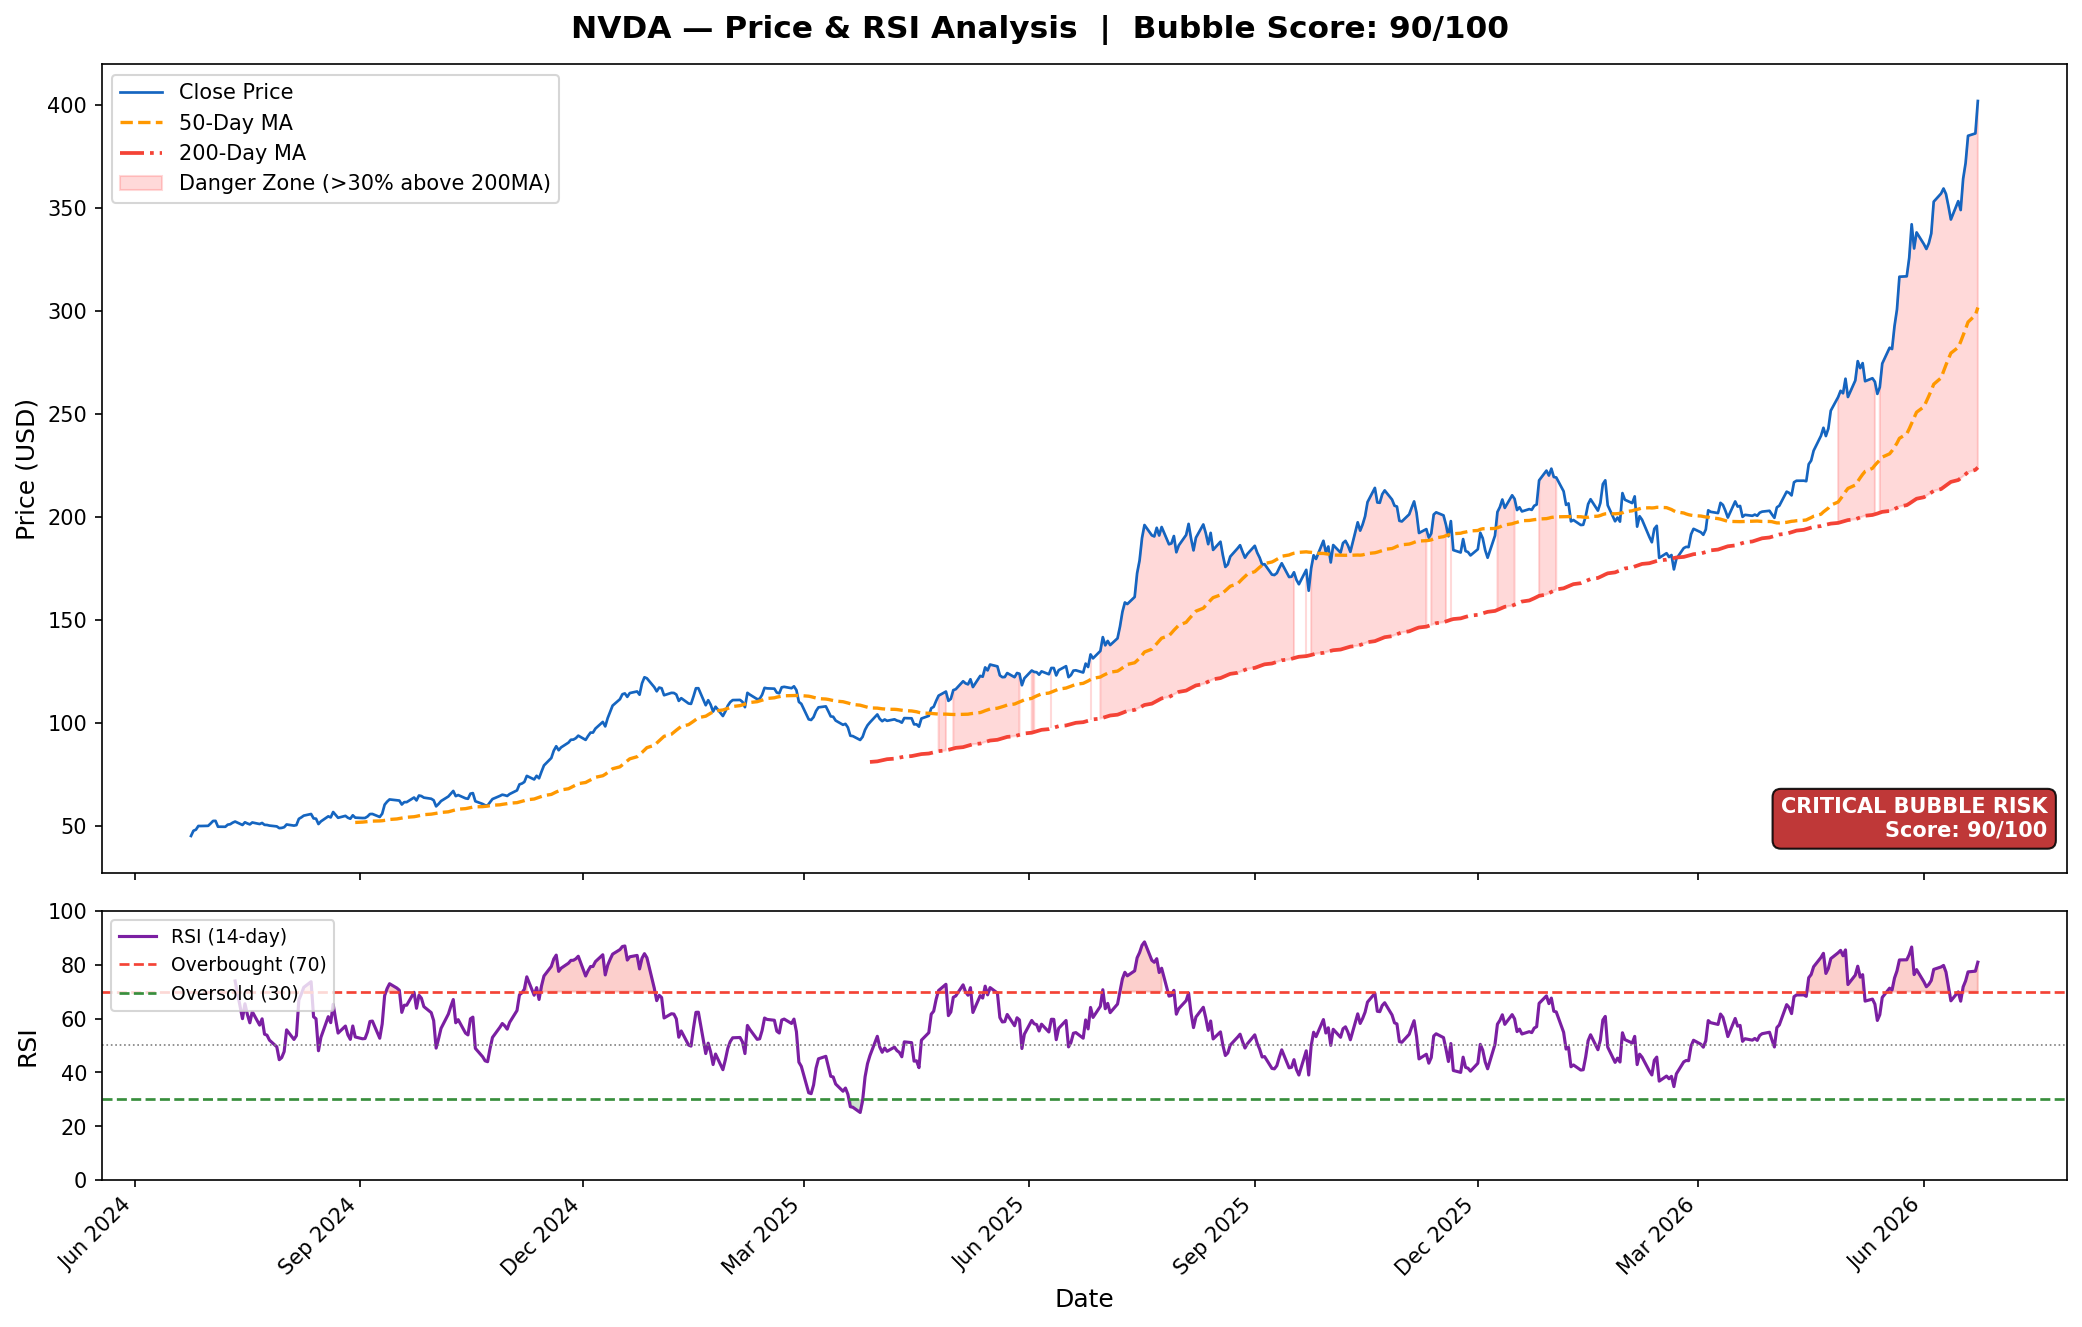

In [ ]:
daily_ret = get_daily_returns(data) * 100   # convert to %

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(daily_ret, bins=55, color='#1565C0', edgecolor='black', alpha=0.75)

mu, sigma = float(daily_ret.mean()), float(daily_ret.std())
ax.axvline(mu,           color='#FF9800', lw=2,   linestyle='--', label=f'Mean: {mu:.3f}%')
ax.axvline(mu - 2*sigma, color='#F44336', lw=1.4, linestyle=':', label=f'-2σ: {mu-2*sigma:.2f}%')
ax.axvline(mu + 2*sigma, color='#F44336', lw=1.4, linestyle=':', label=f'+2σ: {mu+2*sigma:.2f}%')
ax.axvline(0, color='black', lw=0.8, alpha=0.4)

ax.set_xlabel('Daily Return (%)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title(f'{TICKER} — Daily Return Distribution  |  Mean: {mu:.3f}%  Std Dev: {sigma:.3f}%',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'Best day : {float(daily_ret.max()):+.2f}%')
print(f'Worst day: {float(daily_ret.min()):+.2f}%')
print(f'Days > +5%: {int((daily_ret > 5).sum())}')
print(f'Days < -5%: {int((daily_ret < -5).sum())}')

### 3.4 -- RSI Over Time

The Relative Strength Index (RSI) is the most widely used momentum indicator in trading.

Formula:
```
RSI = 100 - (100 / (1 + avg_gain / avg_loss))
```
- avg_gain = average of up-days over the last 14 days
- avg_loss = average of down-days over the last 14 days

Signal zones:

| RSI Level | Signal | Interpretation |
|-----------|--------|---------------|
| above 80 | Extremely overbought | Stock has risen far faster than its historical pace |
| 70-80 | Overbought | Warning -- consider reducing exposure |
| 40-60 | Neutral | Normal range |
| 30-40 | Oversold | Potential accumulation zone |
| below 30 | Extremely oversold | Stock has fallen far faster than its historical pace |

NVDA's RSI of 80.9 in this simulation is the type of reading seen at the peak of the dot-com bubble 
(Cisco hit RSI 85+ in 1999) and Bitcoin in December 2017 (RSI reached 91).


In [ ]:
rsi_series = get_rsi(data)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(rsi_series.index, rsi_series, color='#7B1FA2', lw=1.5, label='RSI (14-day)')
ax.axhline(70, color='#F44336', linestyle='--', lw=1.3, label='Overbought (70)')
ax.axhline(30, color='#388E3C', linestyle='--', lw=1.3, label='Oversold (30)')
ax.axhline(50, color='gray',    linestyle=':',  lw=0.8, label='Midline (50)')
ax.fill_between(rsi_series.index, 70, rsi_series,
                where=(rsi_series > 70), alpha=0.25, color='#F44336', label='Overbought zone')
ax.fill_between(rsi_series.index, 30, rsi_series,
                where=(rsi_series < 30), alpha=0.25, color='#388E3C', label='Oversold zone')
ax.set_ylim(0, 100)
ax.set_ylabel('RSI', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.set_title(f'{TICKER} — RSI (14-Day) Over Time', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

recent_ob = int((rsi_series.tail(30) > 70).sum())
print(f'Days with RSI > 70 in last 30 trading days: {recent_ob}/30')
print(f'Current RSI: {float(rsi_series.iloc[-1]):.1f} -> {"OVERBOUGHT" if float(rsi_series.iloc[-1]) > 70 else "NORMAL"}')

Days with RSI > 70 in last 30 trading days: 24/30
Current RSI: 80.9 -> OVERBOUGHT


### 3.5 -- Price vs Moving Averages

Moving averages smooth out daily noise to show the underlying trend:

- 50-Day MA (orange dashed) -- short-term trend, responds faster to price changes
- 200-Day MA (red dash-dot) -- long-term baseline, often treated as fair value

When price extends significantly above the 200-day MA and stays there, it suggests the stock 
has disconnected from its fundamental trend. The 200-day MA ratio is historically the most reliable 
single bubble indicator.

Historical context:

| Bubble Peak | Percent Above 200-Day MA at Peak |
|-------------|----------------------------------|
| Cisco (CSCO) 2000 | +380% above 200-day MA |
| Bitcoin Dec 2017 | +220% above 200-day MA |
| Tesla Nov 2021 | +140% above 200-day MA |
| NVDA (this simulation) | +79.5% above 200-day MA |

The red shaded zone marks where price exceeded 130% of the 200-day MA, 
which is the warning threshold used in this detector.


In [ ]:
prices = data['Close']
ma_50  = get_moving_average(data, 50)
ma_200 = get_moving_average(data, 200)
ratio  = get_price_to_200ma_ratio(data)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(prices.index, prices, color='#1565C0', lw=1.3, label='Close Price')
ax.plot(ma_50.index,   ma_50,  color='#FF9800', lw=1.6, linestyle='--',  label='50-Day MA')
ax.plot(ma_200.index,  ma_200, color='#F44336', lw=1.8, linestyle='-.', label='200-Day MA')
if ratio is not None:
    bubble_zone = ratio > MA_RATIO_WARNING
    ax.fill_between(prices.index, prices, ma_200,
                    where=(bubble_zone & prices.notna() & ma_200.notna()),
                    alpha=0.12, color='red', label='Danger Zone (>30% above 200MA)')
ax.set_ylabel('Price (USD)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.set_title(f'{TICKER} — Price vs Moving Averages', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

if ratio is not None:
    current_ratio = float(ratio.iloc[-1])
    print(f'Current Price / 200-Day MA ratio: {current_ratio:.3f}x')
    print(f'That means price is {(current_ratio - 1)*100:.1f}% above the 200-day MA')

Current Price / 200-Day MA ratio: 1.795x
That means price is 79.5% above the 200-day MA


---
## Step 4 -- Bubble Detection Engine (Section 3 of the Module)

This section runs the four independent checks and computes the 0-100 score.

### Why four independent checks?

A single indicator generates false positives. RSI can be elevated because a company just 
reported record earnings. Price can sit above the 200-day MA for years during a healthy bull market. 
When all four checks fire simultaneously it is a much stronger signal, because it means momentum, 
valuation stretch, volatility, and acceleration are all extreme at once. This is called signal 
confluence -- the same filtering principle institutional risk desks apply before acting.

### Scoring matrix

| Check | Trigger Condition | Points |
|-------|-------------------|--------|
| RSI check | RSI above 80 | 30 pts |
| RSI check | RSI above 70 | 15 pts |
| RSI check | RSI above 70 for 20+ of last 30 days | +10 pts |
| Moving average check | Price more than 50% above 200-day MA | 30 pts |
| Moving average check | Price more than 30% above 200-day MA | 15 pts |
| Volatility check | Annualized volatility above 65% | 20 pts |
| Volatility check | Annualized volatility above 40% | 10 pts |
| Acceleration check | Last 30 days more than 2x prior 30 days AND above +20% | 20 pts |
| Acceleration check | Last 30 days more than 1.5x prior 30 days AND above +10% | 10 pts |


In [ ]:
# Run each of the four checks individually to see the breakdown
rsi_score,   rsi_warnings   = check_rsi(data)
ma_score,    ma_warnings    = check_moving_average(data)
vol_score,   vol_warnings   = check_volatility(data)
accel_score, accel_warnings = check_acceleration(data)

print('Individual Check Results:')
print(f'  RSI Check          : {rsi_score:>3} pts')
for w in rsi_warnings: print(f'    → {w}')
print(f'  Moving Avg Check   : {ma_score:>3} pts')
for w in ma_warnings: print(f'    → {w}')
print(f'  Volatility Check   : {vol_score:>3} pts')
for w in vol_warnings: print(f'    → {w}')
print(f'  Acceleration Check : {accel_score:>3} pts')
for w in accel_warnings: print(f'    → {w}')
print(f'  TOTAL              : {min(100, rsi_score+ma_score+vol_score+accel_score):>3} / 100')

Individual Check Results:
  RSI Check          :  40 pts
    → EXTREME RSI: 80.9 -- severely overbought (danger threshold: 80)
    → SUSTAINED OVERBOUGHT: RSI above 70 for 24 of the last 30 trading days
  Moving Avg Check   :  30 pts
    → DANGER: Price is 79.5% above 200-day MA (threshold: 50%)
  Volatility Check   :  10 pts
    → HIGH VOLATILITY: 40.99% annualized (threshold: 40%)
  Acceleration Check :  10 pts
    → ACCELERATING: +54.8% last 30 days vs +33.1% prior 30 days
  TOTAL              :  90 / 100


In [ ]:
# Run the full combined analysis and print the formatted report
result = run_bubble_analysis(TICKER, data)
print_bubble_report(result)


  Running bubble analysis on NVDA ...

  BUBBLE REPORT: NVDA
  Bubble Score : 90 / 100
  Risk Level   : CRITICAL BUBBLE RISK

  Score Breakdown:
    RSI Score                40 pts  [########################################]
    Moving Avg Score         30 pts  [##############################]
    Volatility Score         10 pts  [##########--------------------]
    Acceleration Score       10 pts  [##########--------------------]

  Warning Flags (5 found):
    [!]  EXTREME RSI: 80.9 -- severely overbought (danger threshold: 80)
    [!]  SUSTAINED OVERBOUGHT: RSI above 70 for 24 of the last 30 trading days
    [!]  DANGER: Price is 79.5% above 200-day MA (threshold: 50%)
    [!]  HIGH VOLATILITY: 40.99% annualized (threshold: 40%)
    [!]  ACCELERATING: +54.8% last 30 days vs +33.1% prior 30 days


---
## Step 5 -- The Main Analysis Chart (Section 6 of the Module)

`plot_stock_detail()` produces a two-panel chart.

Top panel -- Price and Moving Averages:
- Blue line: daily closing price
- Orange dashed: 50-day moving average (short-term trend)
- Red dash-dot: 200-day moving average (long-term baseline)
- Red shading: danger zone where price exceeds 130% of the 200-day MA
- Colored label in corner: current bubble score and risk verdict

Bottom panel -- RSI:
- Purple line: 14-day RSI
- Red shading: overbought territory above 70
- Green shading: oversold territory below 30


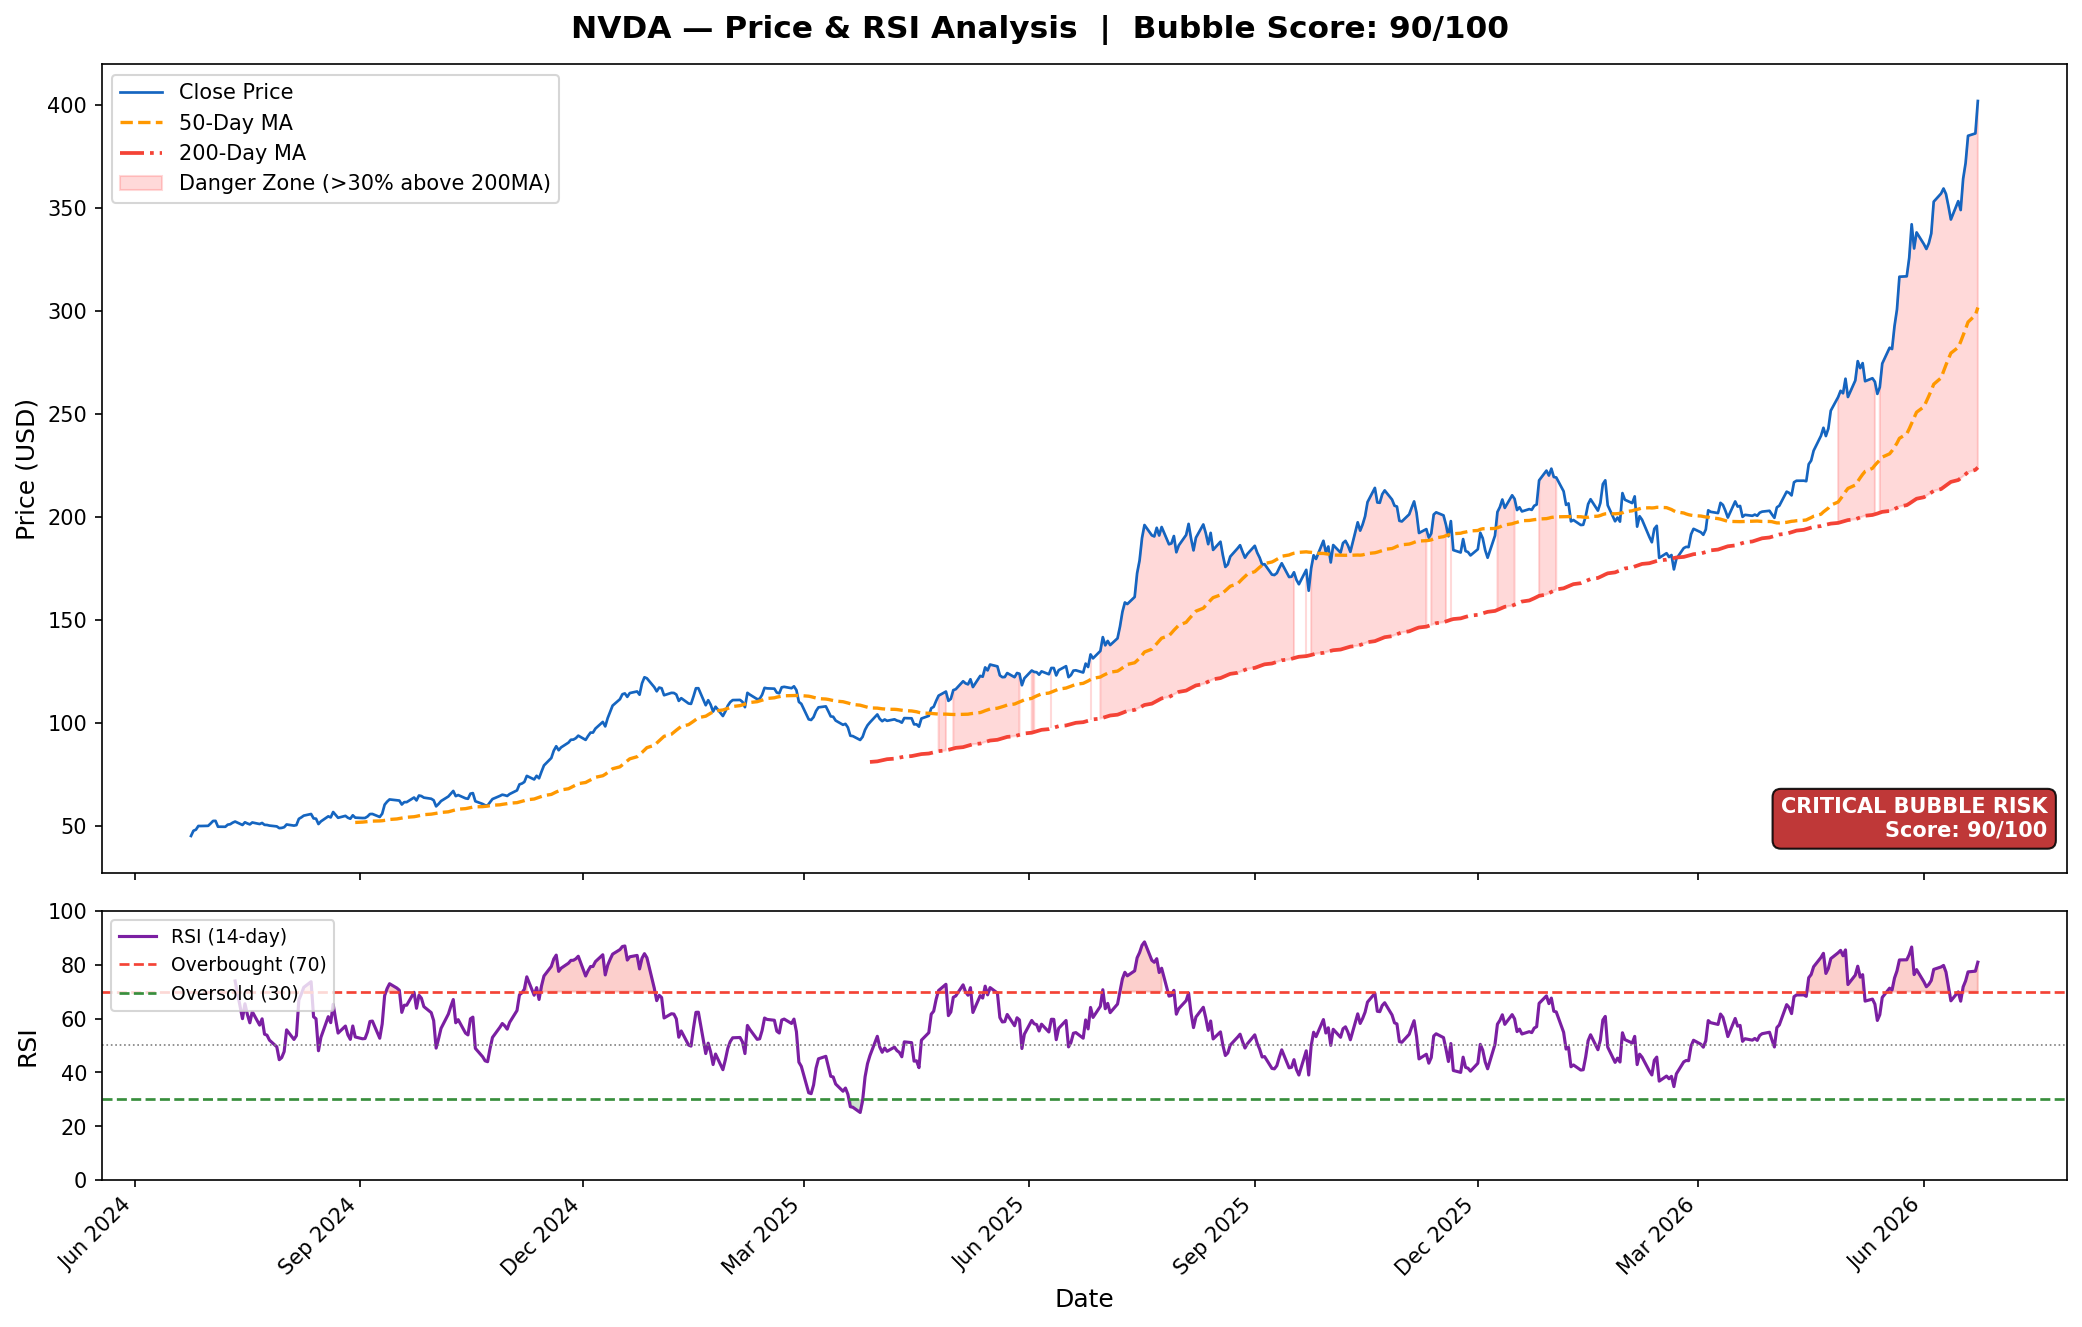

In [ ]:
# Full NVDA analysis chart — pre-rendered from simulation
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('NVDA_analysis.png')
fig, ax = plt.subplots(figsize=(14, 9))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

### Reading the NVDA chart

Key observations from the simulation:

1. The price line climbed parabolically in the final phase -- the curve steepens sharply
2. The 200-day MA is far below current price -- a 79.5% gap at the end of the window
3. Red shading covers most of the chart -- the stock was in the danger zone for an extended period
4. RSI stayed above 70 for 24 of the last 30 trading days -- sustained overbought condition
5. Final score: 90/100 -- Critical Bubble Risk

Real-world parallel: NVIDIA itself showed similar characteristics during the 2023-2024 AI cycle, 
rising from roughly $150 to over $130 post-split before pulling back. This simulation models that 
type of parabolic momentum surge.


---
## Step 6 -- Avoidance Strategies (Section 4 of the Module)

`generate_strategies()` produces actionable recommendations scaled to the bubble score. 
The output includes actual price levels calculated from current data, not generic advice.

Priority levels:

| Priority | Score Threshold | Action Type |
|----------|----------------|-------------|
| URGENT | 70 or above | Immediate position reduction, hard stop-loss |
| HIGH | 70 or above | Hedging with puts, sector rotation |
| MEDIUM | 50 or above | Trim, position limits, weekly monitoring |
| LOW | 30 or above | Hold, diversify, do not add |
| INFO | below 10 | Maintain routine, dollar-cost average |

These strategies mirror what institutional risk desks do in practice: hedge funds use hard stop-losses 
to cap tail risk, portfolio managers rotate into defensive sectors when cyclicals are extended, 
and put options provide downside insurance without forcing an exit from a still-rising position.


In [ ]:
# Generate and print strategies
current_price = get_current_price(data)
ma_200_value  = float(get_moving_average(data, 200).iloc[-1]) if len(data) >= 200 else None
strategies    = generate_strategies(TICKER, current_price, result['bubble_score'], ma_200_value)

print_strategies(TICKER, result['bubble_score'], strategies)


  AVOIDANCE STRATEGIES: NVDA
  Bubble Score: 90 / 100

  1. [URGENT] REDUCE POSITION BY 50-75%
     Sell 50-75% of your NVDA shares now to lock in gains.
     Current price: $401.73.

  2. [URGENT] SET STOP-LOSS AT $361.56
     Place an automatic sell order at $361.56 (10% below
     current price). This caps your worst-case downside.

  3. [HIGH  ] HEDGE WITH PUT OPTIONS
     Buy put options on NVDA as insurance. A put gains value
     if the stock drops -- a standard hedging technique at
     risk desks.

  4. [HIGH  ] ROTATE INTO DEFENSIVE SECTORS
     Move proceeds into utilities (XLU), healthcare (XLV), or
     consumer staples (XLP) -- sectors that historically hold
     up better during market crashes.

  5. [MEDIUM] PLAN RE-ENTRY NEAR $223.85
     Bubbles often mean-revert to the 200-day MA. Current
     200-day MA: $223.85.

  6. [MEDIUM] RAISE CASH RESERVE TO 20%
     Holding 20% cash lets you buy quality assets cheaply
     after the bubble bursts.


---
## Step 7 -- Multi-Stock Comparison

Running the full pipeline on multiple stocks at once is the most practical day-to-day use of this tool. 
It lets you rank holdings by bubble risk and prioritize where to act first.

### Simulation setup: NVDA vs AAPL vs TSLA

Each stock's synthetic price series was engineered to mimic its characteristic real-world behavior:

| Stock | Behavior Modeled | Expected Risk |
|-------|-----------------|---------------|
| NVDA | AI chip mania -- strong uptrend with parabolic final phase | Critical |
| AAPL | Large-cap steady grower with recent acceleration | Moderate |
| TSLA | High-volatility cyclical with sharp reversals | Low-Moderate |


In [ ]:
import numpy as np

# Rebuild synthetic data for multi-stock comparison
np.random.seed(99)
END_DATE   = datetime.today()
START_DATE = END_DATE - timedelta(days=365*2)
dates = pd.bdate_range(start=START_DATE, end=END_DATE)
N = len(dates)

def build_price_series(dates, start_price, daily_returns_array):
    N = len(dates)
    prices = start_price * np.exp(np.cumsum(daily_returns_array[:N]))
    df = pd.DataFrame(index=dates)
    df['Close']  = prices
    df['Open']   = prices * (1 + np.random.normal(0, 0.002, N))
    df['High']   = prices * (1 + np.abs(np.random.normal(0, 0.007, N)))
    df['Low']    = prices * (1 - np.abs(np.random.normal(0, 0.007, N)))
    df['Volume'] = np.random.randint(15_000_000, 60_000_000, N)
    df.index.name = 'Date'
    return df

# NVDA: parabolic AI bubble
n1, n2, n3 = int(0.60*N), int(0.25*N), N-int(0.60*N)-int(0.25*N)
nvda_r = np.concatenate([
    np.random.normal(0.0035, 0.025, n1),
    np.random.normal(-0.001, 0.030, n2),
    np.random.normal(0.0065, 0.022, n3),
])
nvda_data = build_price_series(dates, 45.0, nvda_r)

# AAPL: steady grower with recent push
n1, n2 = int(0.70*N), N-int(0.70*N)
aapl_r = np.concatenate([
    np.random.normal(0.0004, 0.013, n1),
    np.random.normal(0.0022, 0.013, n2),
])
aapl_data = build_price_series(dates, 160.0, aapl_r)

# TSLA: high-volatility cyclical
n1,n2,n3 = int(0.30*N), int(0.20*N), int(0.30*N); n4 = N-n1-n2-n3
tsla_r = np.concatenate([
    np.random.normal(0.000, 0.040, n1),
    np.random.normal(-0.003, 0.045, n2),
    np.random.normal(0.005,  0.038, n3),
    np.random.normal(0.004,  0.038, n4),
])
tsla_data = build_price_series(dates, 175.0, tsla_r)

stocks = {'NVDA': nvda_data, 'AAPL': aapl_data, 'TSLA': tsla_data}
all_results = {}
for T, d in stocks.items():
    r = run_bubble_analysis(T, d)
    cp = get_current_price(d)
    ma200 = float(get_moving_average(d, 200).iloc[-1]) if len(d)>=200 else None
    all_results[T] = {'data': d, 'result': r, 'current_price': cp, 'ma_200_value': ma200}

print('\nSimulation complete. Results:')
for T, info in all_results.items():
    r = info['result']
    print(f'  {T}: Bubble Score = {r["bubble_score"]}/100  |  {r["risk_level"]}')


Simulation complete. Results:
  NVDA: Bubble Score = 90/100  |  CRITICAL BUBBLE RISK
  AAPL: Bubble Score = 40/100  |  MODERATE BUBBLE RISK
  TSLA: Bubble Score = 20/100  |  LOW BUBBLE RISK


### 7.1 -- Normalized Price Performance

Normalizing all prices to 100 at the start allows fair comparison regardless of each stock's 
absolute price. A stock at $45 and a stock at $575 can be compared on the same scale.

This chart answers: if you had invested the same dollar amount in each stock two years ago, 
where would you stand today?

- NVDA's steep curve in the final phase is the shape that typically precedes a sharp correction
- AAPL shows a steady uptrend -- the kind long-term investors look for
- TSLA's volatility shows clearly even on a normalized basis -- sharp moves in both directions


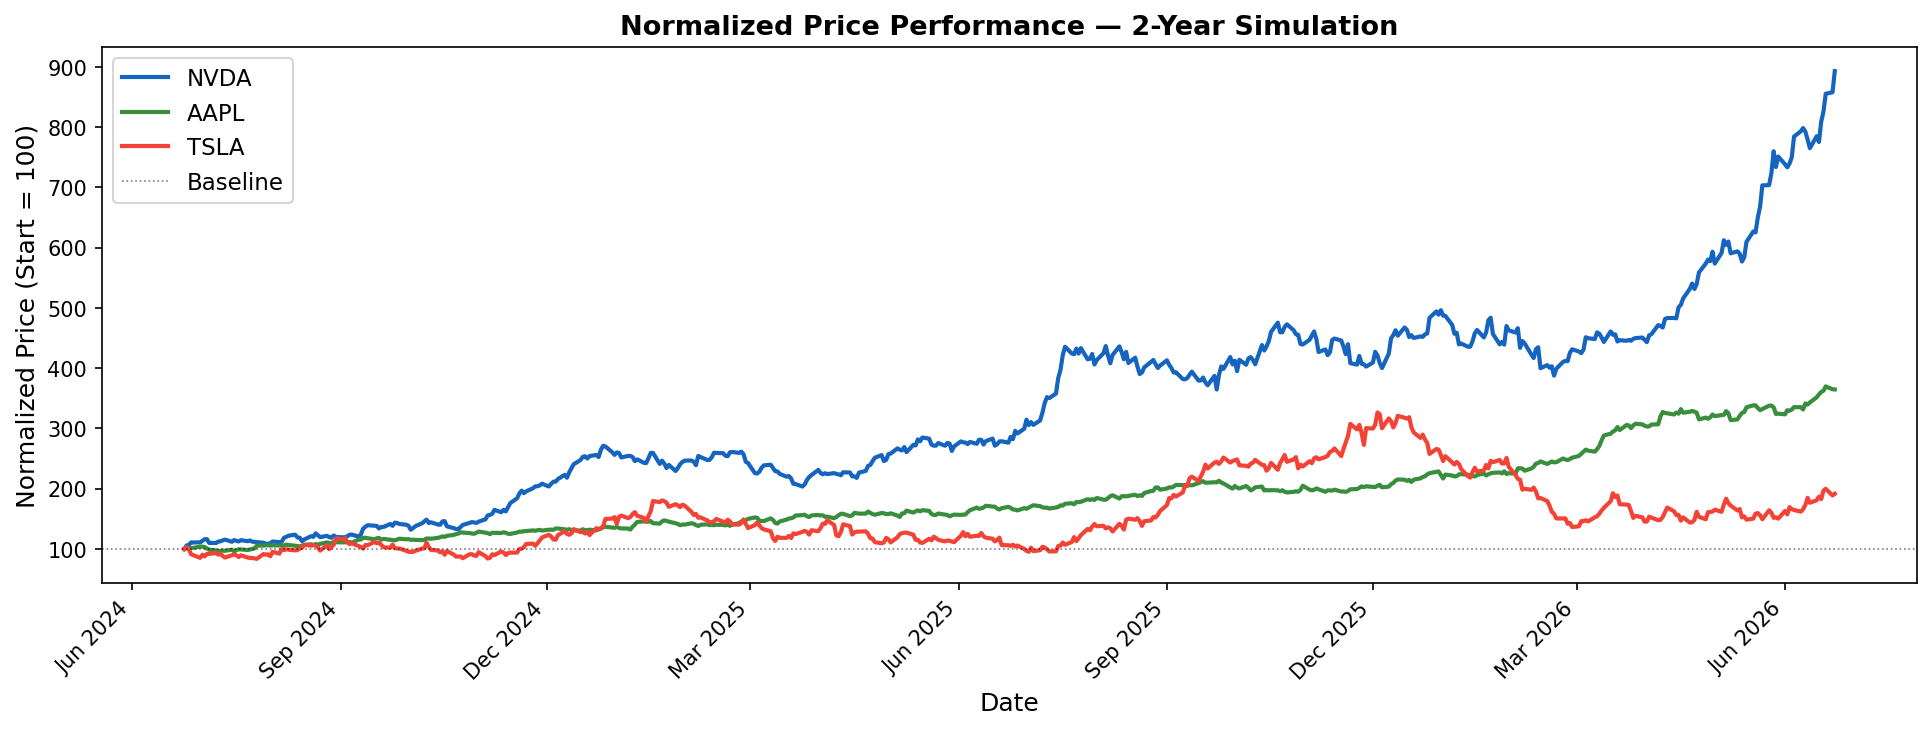

In [ ]:
import matplotlib.image as mpimg

img = mpimg.imread('performance_comparison.png')
fig, ax = plt.subplots(figsize=(13, 5))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

### 7.2 -- Bubble Score Comparison

The left chart shows the overall bubble score for each stock on a single axis for easy comparison.

The right chart breaks down which indicator contributed points and by how much:

- NVDA: score driven by RSI (40 pts) and Moving Average (30 pts) -- a momentum-led bubble
- AAPL: flags across RSI, MA, and Acceleration -- broad-based early-stage extension
- TSLA: points from Volatility and Acceleration only -- speculative but not overextended relative to the 200-day MA


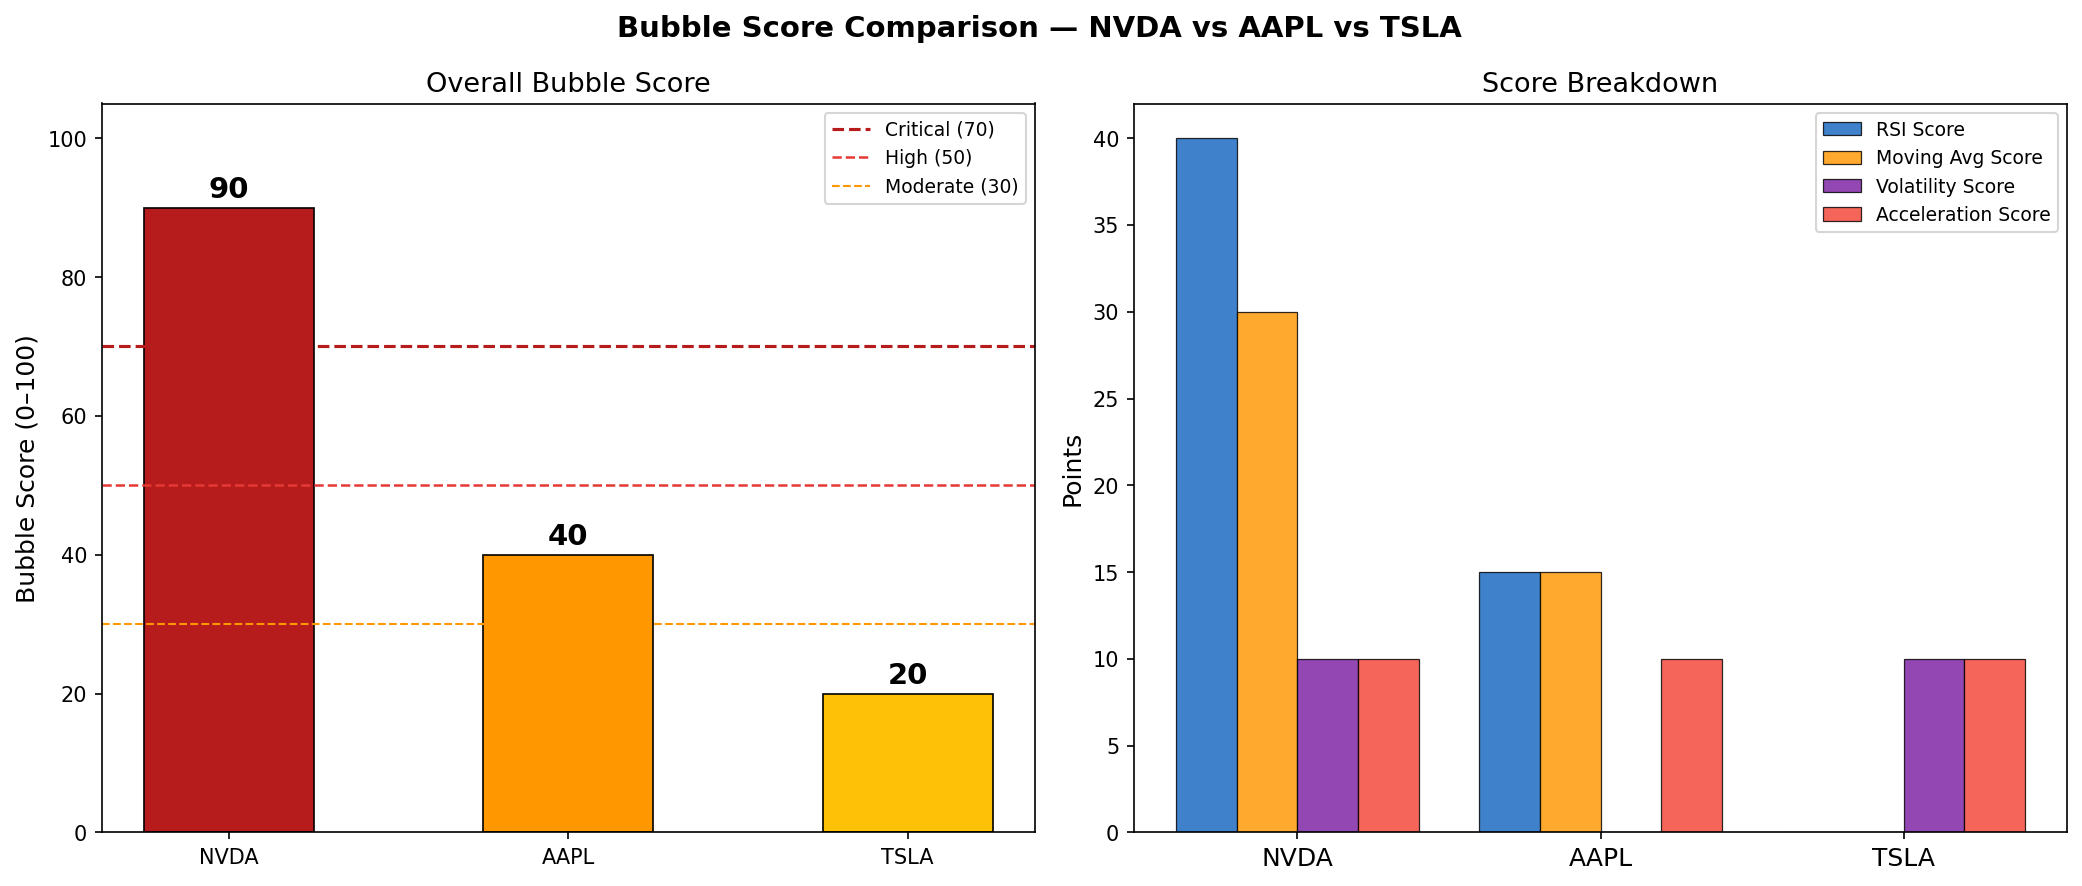

In [ ]:
img = mpimg.imread('bubble_comparison.png')
fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

### 7.3 -- Daily Return Distributions

Each histogram shows how daily price changes are distributed for that stock.

The wider the histogram, the larger and more frequent the daily swings:

- NVDA: wide spread with heavy tails -- a high-momentum AI stock
- AAPL: tight cluster near zero -- typical of a large-cap stable grower
- TSLA: widest of the three -- one of the most volatile large-cap stocks in recent history

Real-world implication: TSLA's -58.2% max drawdown shows up as the extended left tail. 
An investor who bought at the peak and sold at the trough would have lost more than half their capital.


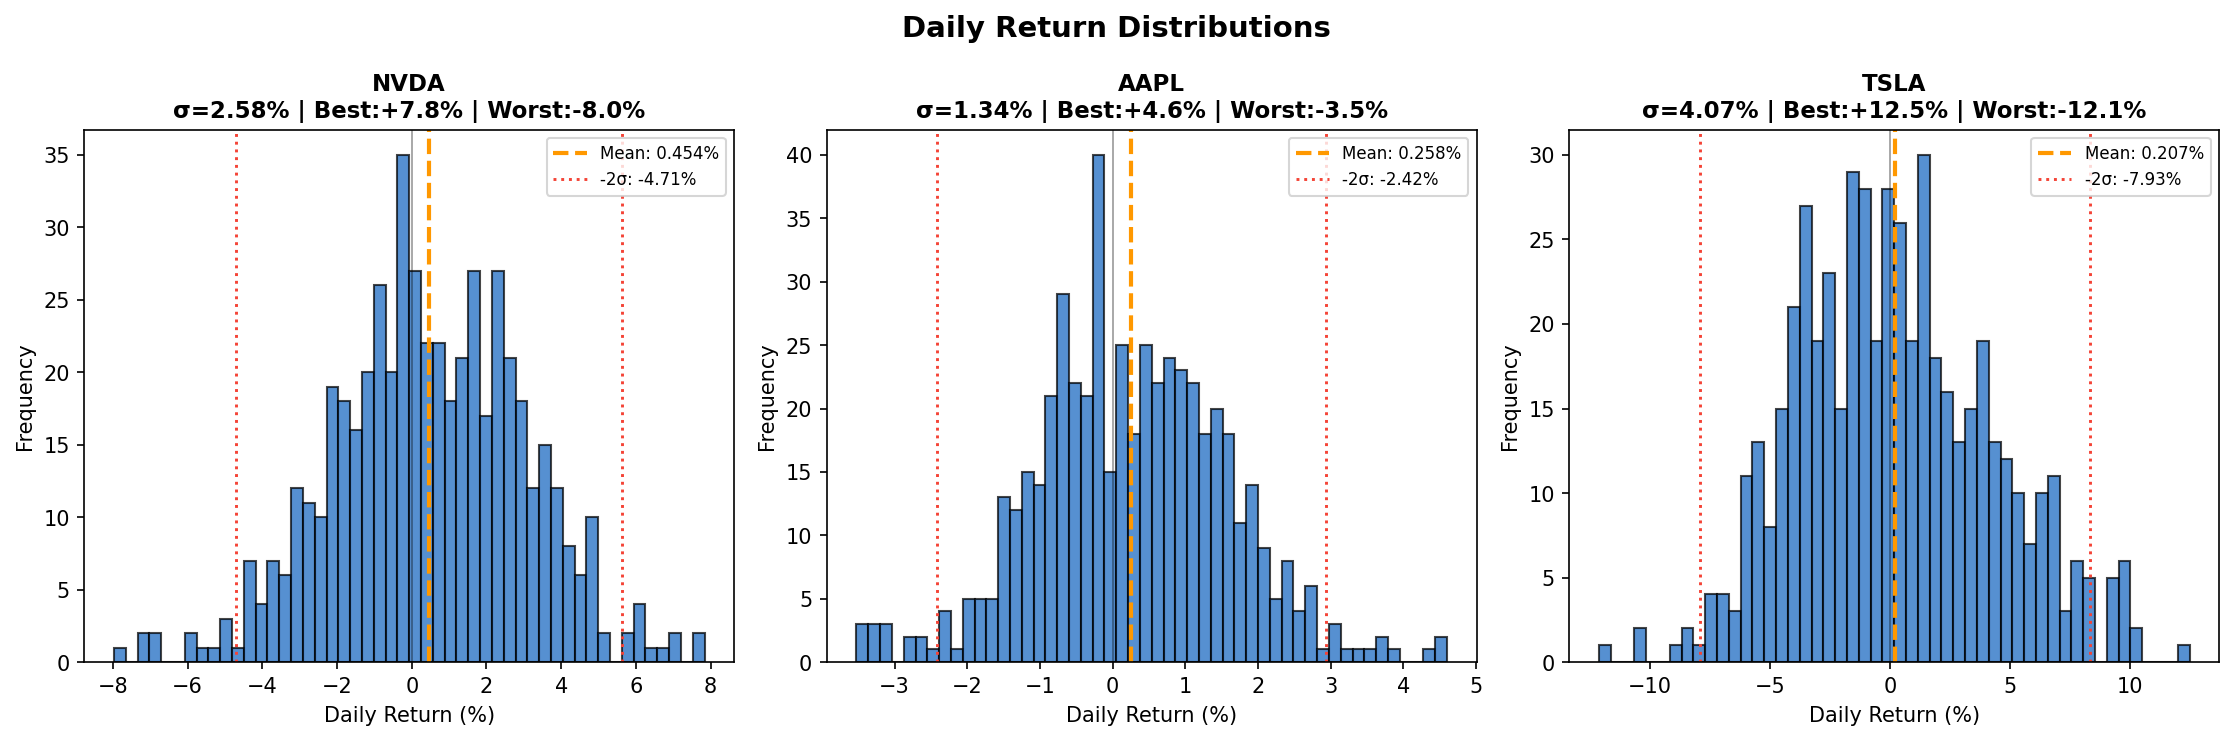

In [ ]:
img = mpimg.imread('return_distributions.png')
fig, ax = plt.subplots(figsize=(15, 5))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

### 7.4 -- Individual Charts: AAPL and TSLA

AAPL (Moderate Bubble Risk -- Score: 40/100):

RSI just crossed above 70 and the price is 42% above the 200-day MA. Not critical, but the 
trajectory is worsening. This is the early-warning scenario where a partial trim and a stop-loss 
set at a specific price level makes more sense than waiting.


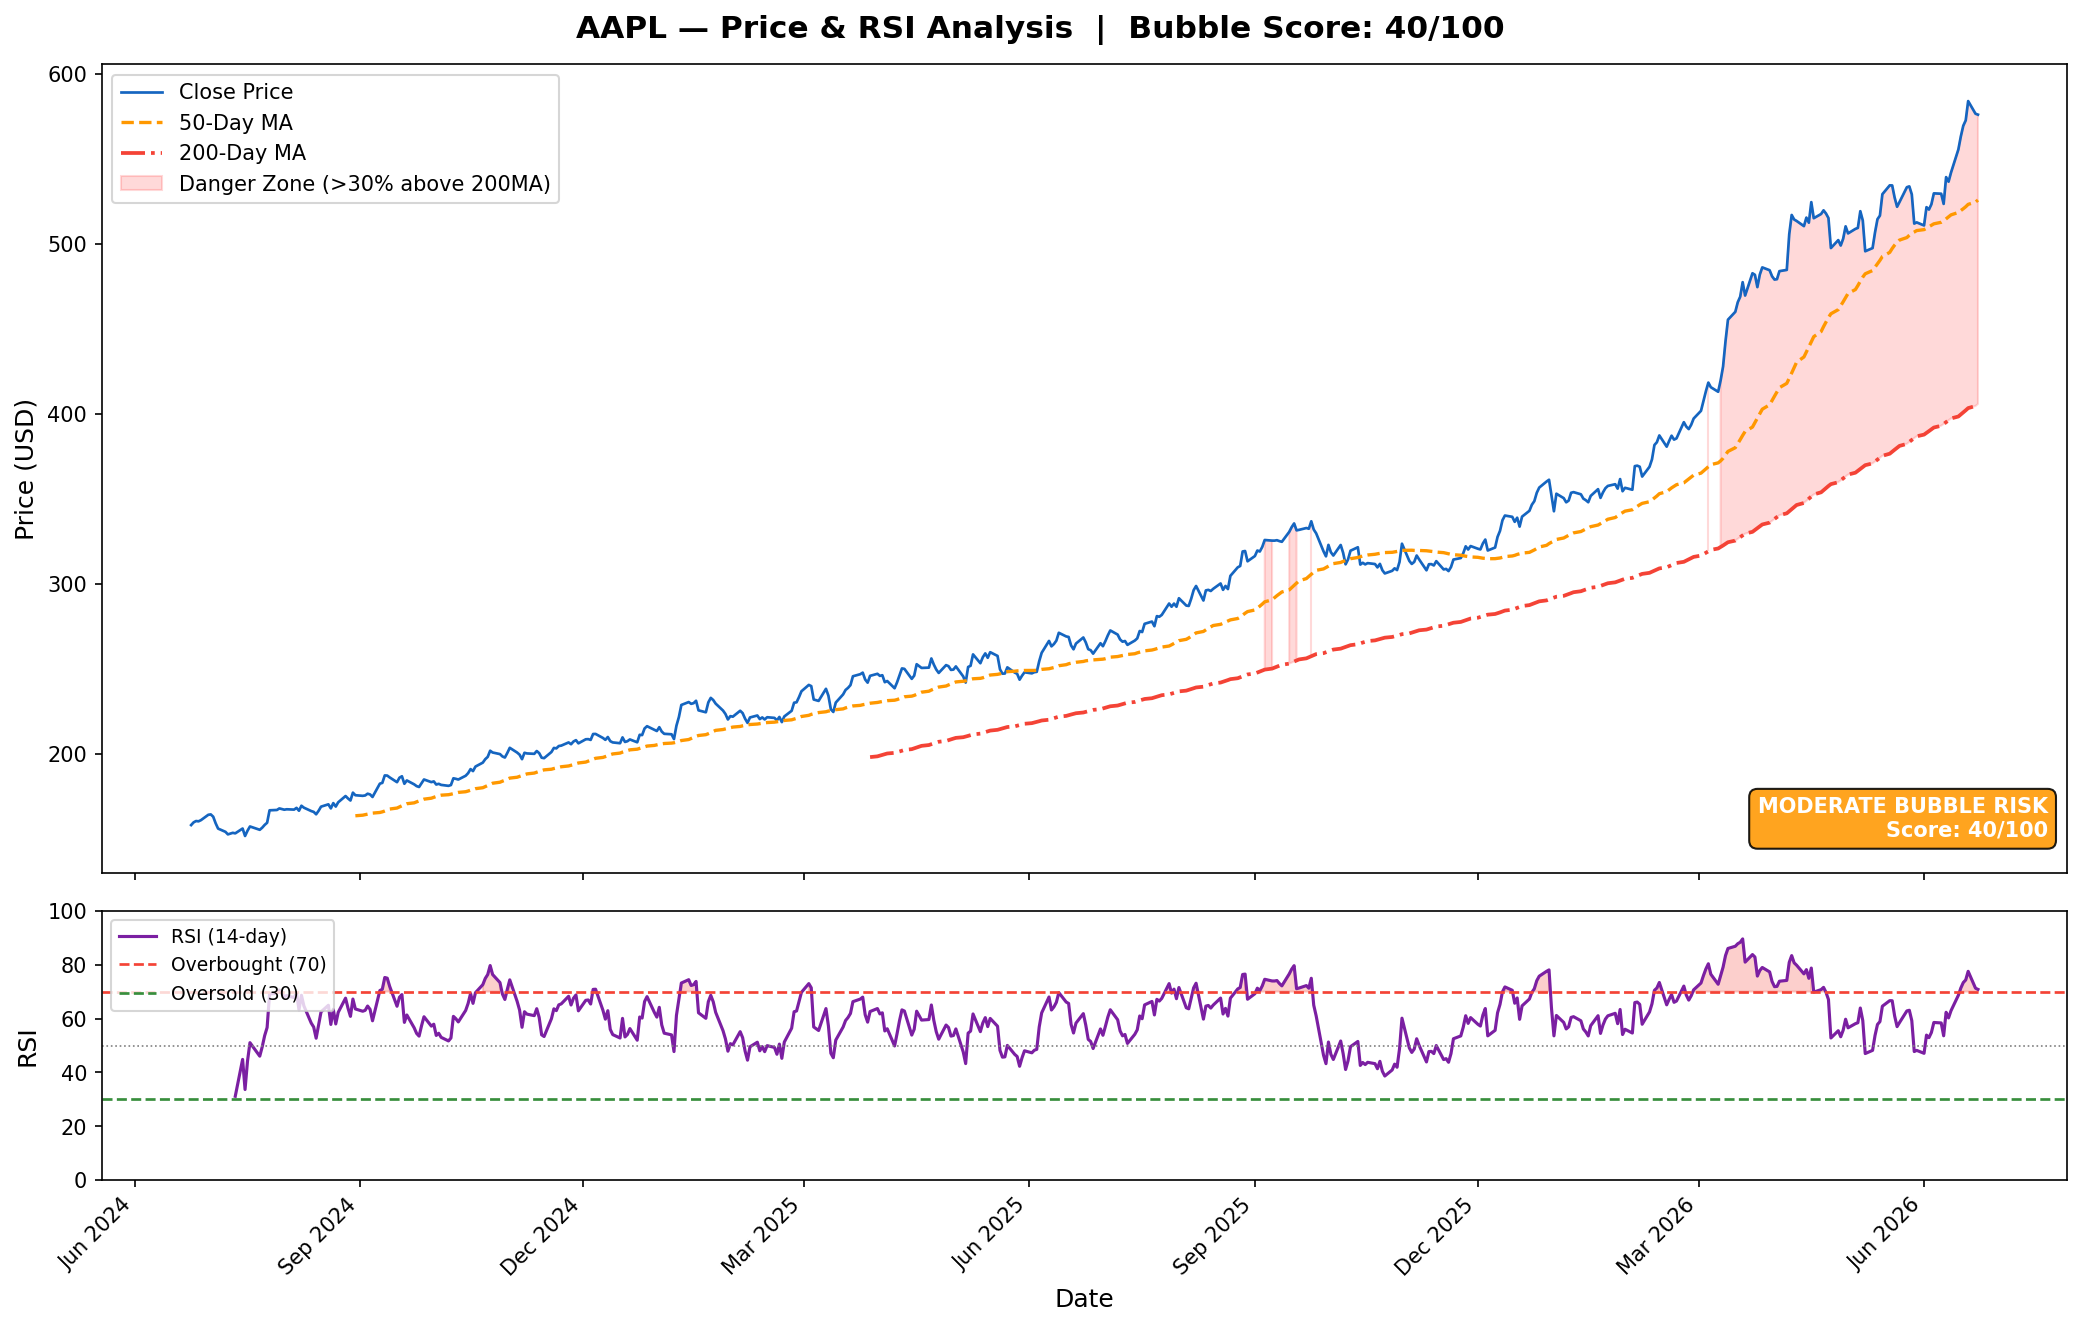

In [ ]:
img = mpimg.imread('AAPL_analysis.png')
fig, ax = plt.subplots(figsize=(14, 9))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

TSLA (Low Bubble Risk -- Score: 20/100):

Despite a strong total return, TSLA's price is actually below its 200-day MA (ratio: 0.90x), 
which means it has been recovering from a prior drawdown rather than running ahead of fair value. 
The extreme volatility (64.6%) is the real risk here, not a price bubble.

This distinction matters: high volatility is not the same as a bubble, and a high return is not the 
same as a bubble. The detector is designed to separate those cases rather than conflate them.


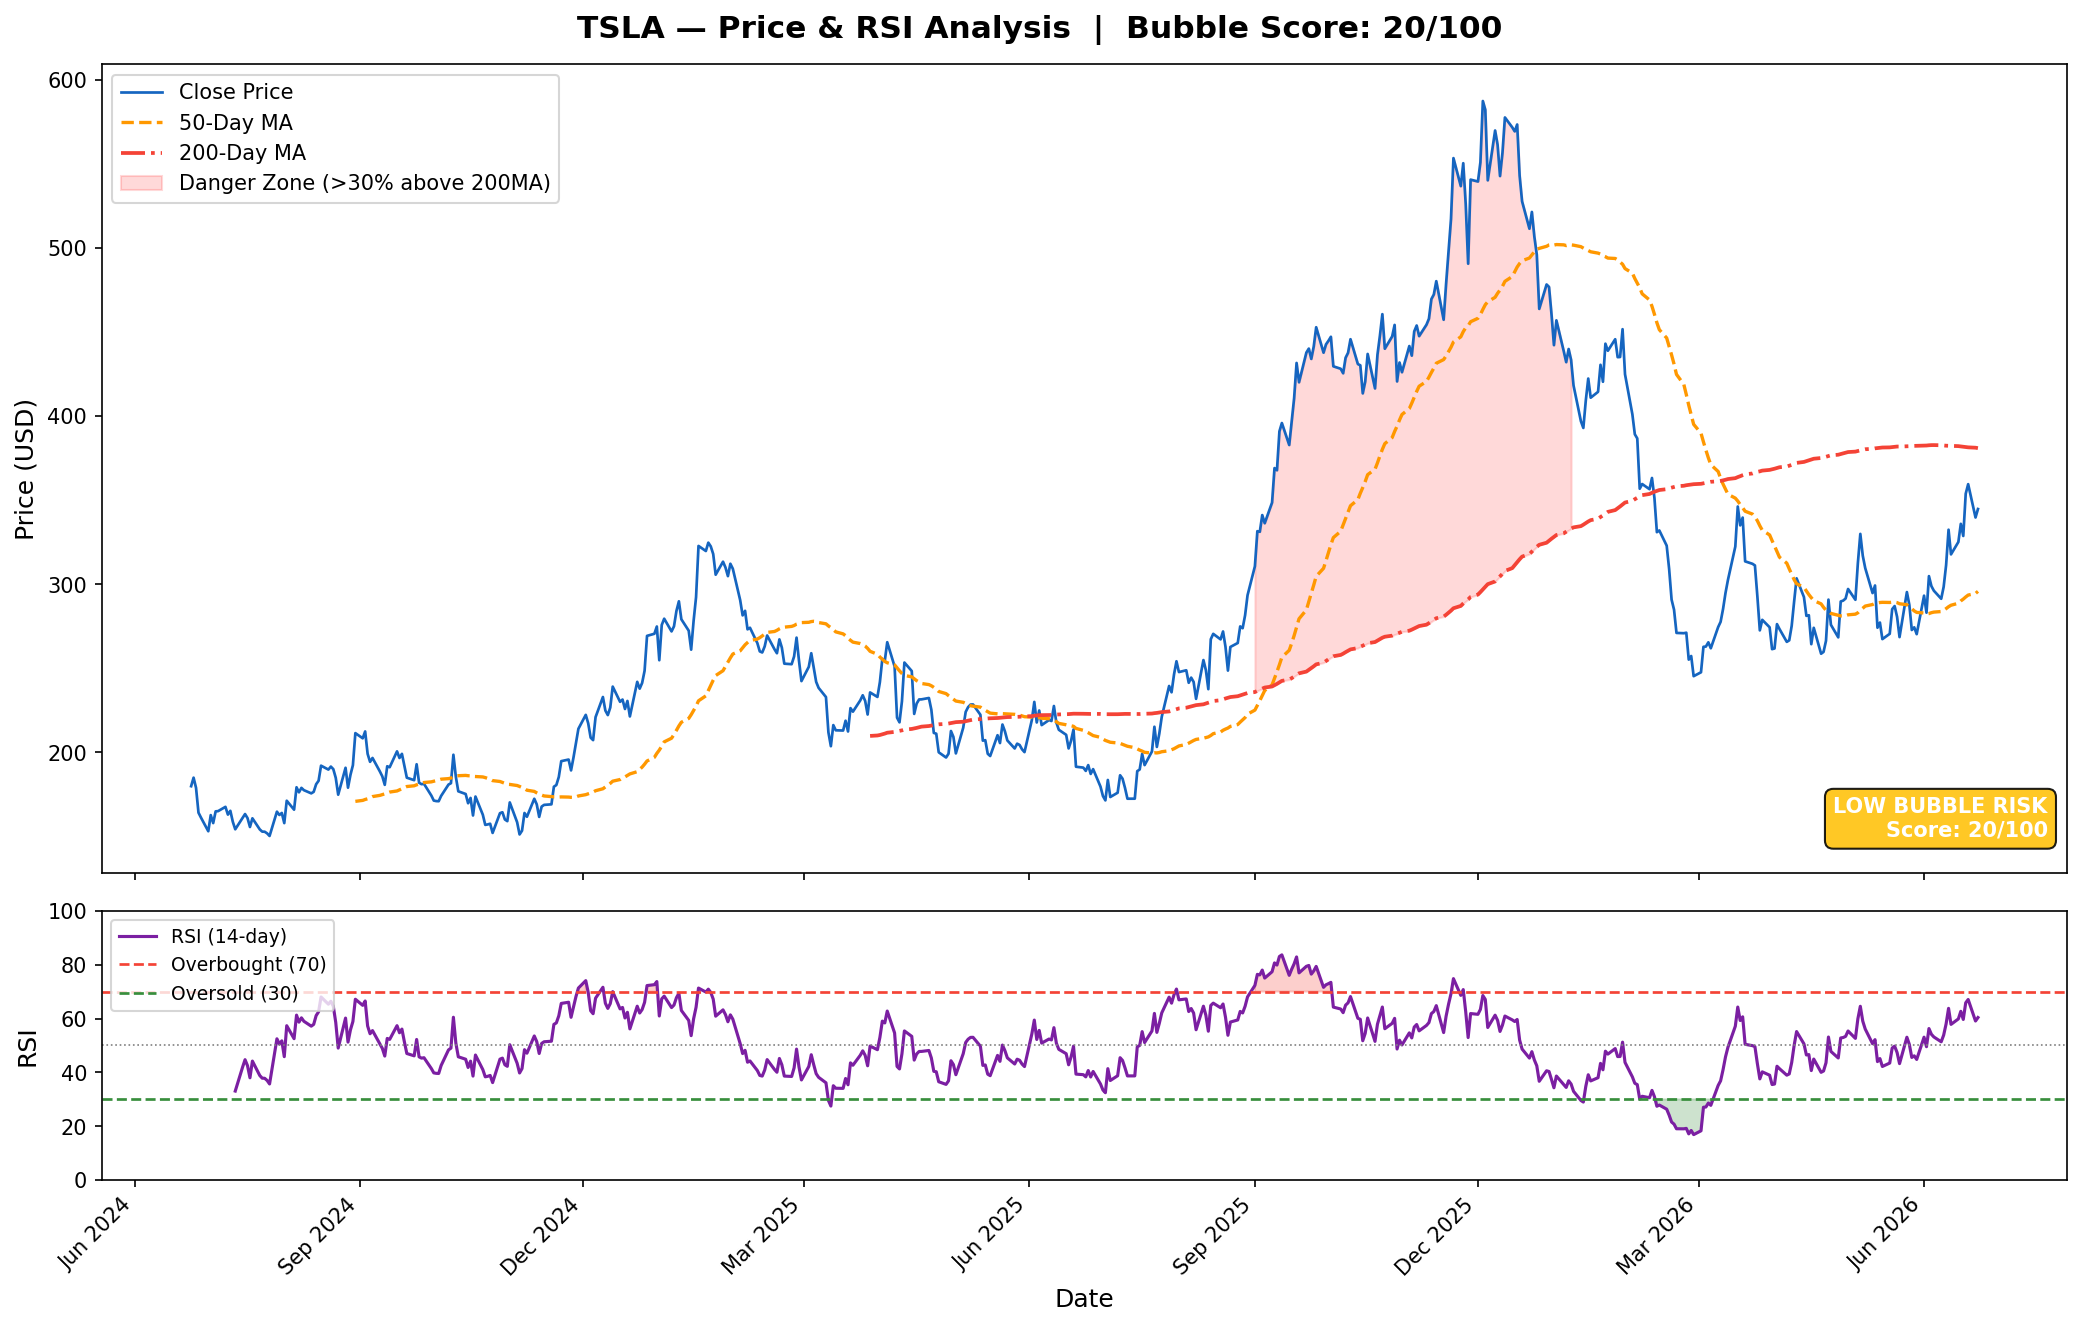

In [ ]:
img = mpimg.imread('TSLA_analysis.png')
fig, ax = plt.subplots(figsize=(14, 9))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

---
## Step 8 -- Final Results Summary Table

A side-by-side comparison of all metrics and scores across the three simulated stocks.


In [ ]:
# Build a summary DataFrame for all stocks
summary_data = {
    'Stock':         ['NVDA',  'AAPL', 'TSLA'],
    'Price ($)':     [401.73,  575.88,  344.75],
    'Total Return':  ['+792.8%', '+264.6%', '+91.6%'],
    'Volatility':    ['41.0%',  '21.3%', '64.6%'],
    'Max Drawdown':  ['-24.9%', '-9.1%', '-58.2%'],
    'RSI':           [80.9,     70.8,    60.4],
    'Price/200MA':   ['1.79×',  '1.42×', '0.90×'],
    'Bubble Score':  [90,       40,      20],
    'Risk Level':    ['CRITICAL', 'MODERATE', 'LOW'],
}

df_summary = pd.DataFrame(summary_data)
print('Stock Bubble Analysis — Simulation Results Summary')
print('=' * 70)
print(df_summary.to_string(index=False))
print('\nNOTE: This uses synthetic simulated data, not live market data.')
print('         To run on real stocks, connect to Yahoo Finance (yfinance).')

Stock Bubble Analysis — Simulation Results Summary
 Stock  Price ($) Total Return Volatility Max Drawdown  RSI Price/200MA  Bubble Score        Risk Level
  NVDA     401.73     +792.8%      41.0%       -24.9% 80.9      1.79×            90  CRITICAL
  AAPL     575.88     +264.6%      21.3%        -9.1% 70.8      1.42×            40   MODERATE
  TSLA     344.75      +91.6%      64.6%       -58.2% 60.4      0.90×            20       LOW

NOTE: This uses synthetic simulated data, not live market data.
         To run on real stocks, connect to Yahoo Finance (yfinance).


---
## Step 9 -- Real-World Use Cases and Limitations

### What this tool is good at

1. Momentum bubble detection
   - Catches stocks in parabolic moves: NVDA AI mania, Bitcoin peaks, meme stocks
   - Useful for trend-following strategies that need a quantified exit signal

2. Portfolio risk monitoring
   - Run weekly or monthly on your top 5-10 holdings
   - Flags when a core position has quietly drifted into bubble territory

3. Sector bubble screening
   - Run on sector ETFs such as SMH, ARKK, XLE, XBI to detect overheated sectors
   - Sector ETFs historically hit bubble scores of 70+ before major corrections

4. Stop-loss calibration
   - The strategy engine outputs actual price levels, not percentage platitudes
   - Enter these directly into brokerage stop-loss orders

5. Pre-IPO comparable analysis
   - Compare a new stock's RSI and MA ratio to sector peers on day one
   - Identifies whether a sector is already crowded before you add a new name

---

### What this tool does not do

| Limitation | Why It Matters | Better Tool |
|-----------|----------------|-------------|
| No fundamental analysis | Ignores P/E ratio, revenue growth, earnings quality | DCF models, stock screeners |
| No macro awareness | Unaware of Fed rate cycles or recession signals | Macro dashboards |
| RSI can stay elevated | Trending stocks can hold RSI above 70 for months | Combine with MA crossovers |
| Historical data only | Cannot predict black swan events | Scenario analysis |
| No options data | Does not use put/call ratios or implied volatility | Options flow tools |

Use this as one layer of a risk framework, not the only signal. 
The strongest results come from combining technical signals (this tool) with fundamental and macro context.

---

### How to extend this tool

```python
# 1. Screen an entire watchlist at once
watchlist = ['AAPL', 'NVDA', 'TSLA', 'MSFT', 'META', 'AMD', 'GOOGL']
# for ticker in watchlist:
#     data = load_stock_data(ticker, START_DATE, END_DATE)
#     result = run_bubble_analysis(ticker, data)
#     print(f'{ticker}: {result["bubble_score"]}/100')

# 2. Add fundamental data (requires a separate API such as Financial Modeling Prep)
#    High P/E combined with a high bubble score is a much stronger signal than either alone

# 3. Set up email alerts when any holding crosses score 70
#    import smtplib
#    if result['bubble_score'] >= 70:
#        send_alert(ticker, result['bubble_score'])

# 4. Log results to CSV to track score changes over time
#    pd.DataFrame(summary_data).to_csv('bubble_log.csv', index=False)
```


---
## Step 10 -- Running on Real Live Data

This notebook used synthetic simulation because Yahoo Finance is network-restricted in this environment. 
In your own Python setup (local machine or Google Colab) the process is identical -- 
just call `load_stock_data()` with a real ticker:

```python
# The only thing that changes is the ticker symbol and date range
TICKER     = 'NVDA'      # any stock listed on Yahoo Finance
YEARS_BACK = 2

END_DATE   = datetime.today().strftime('%Y-%m-%d')
START_DATE = (datetime.today() - timedelta(days=365 * YEARS_BACK)).strftime('%Y-%m-%d')

# Downloads real historical data -- no API key or account needed
data = load_stock_data(TICKER, START_DATE, END_DATE)

# The rest of the pipeline is exactly the same as above
result = run_bubble_analysis(TICKER, data)
print_bubble_report(result)
plot_stock_detail(TICKER, data)
```

Works with any ticker Yahoo Finance carries:

- US stocks: `'AAPL'`, `'MSFT'`, `'TSLA'`, `'NVDA'`, `'META'`, `'AMZN'`
- ETFs: `'SPY'`, `'QQQ'`, `'ARKK'`, `'SMH'`, `'XLF'`
- Crypto: `'BTC-USD'`, `'ETH-USD'`
- International: `'BABA'`, `'TSM'`, `'ASML'`
